# PLAN DU NOTEBOOK FINAL


Projet SID – Analyse Statistique Comparative et Machine Learning pour la Détection de l'ASD

1. Introduction
2. Présentation des données
PARTIE I - Analyse statistique comparative
3. Préparation des données pour l'analyse statistique
4. Analyse statistique comparative
PARTIE II - Modélisation et Machine Learning
5. Prétraitement des données pour la modélisation
6. Analyse exploratoire des données (EDA)
7. Modélisation et apprentissage automatique
8. Discussion générale
9. Conclusion générale


## 1. Introduction

Objectifs, problématique et contexte du projet.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

df1 = pd.read_csv('Data1.csv')
df2 = pd.read_csv('Data2.csv')

print(df1.shape, df2.shape)


(704, 21) (800, 22)


## 2. Présentation des datasets

Chargement et description de Data1 et Data2.

In [3]:
# =====================================================
# 2. PRESENTATION DES DATASETS
# =====================================================

import pandas as pd

df1 = pd.read_csv("Data1.csv")
df2 = pd.read_csv("Data2.csv")

print("Dataset 1")
print(df1.shape)
display(df1.head())

print("\nDataset 2")
print(df2.shape)
display(df2.head())

Dataset 1
(704, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO



Dataset 2
(800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [4]:
# Informations générales

print("========== DATASET 1 ==========")
print(df1.info())

print("\n========== DATASET 2 ==========")
print(df2.info())

========== DATASET 1 ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A1_Score         704 non-null    int64 
 1   A2_Score         704 non-null    int64 
 2   A3_Score         704 non-null    int64 
 3   A4_Score         704 non-null    int64 
 4   A5_Score         704 non-null    int64 
 5   A6_Score         704 non-null    int64 
 6   A7_Score         704 non-null    int64 
 7   A8_Score         704 non-null    int64 
 8   A9_Score         704 non-null    int64 
 9   A10_Score        704 non-null    int64 
 10  age              704 non-null    object
 11  gender           704 non-null    object
 12  ethnicity        704 non-null    object
 13  jundice          704 non-null    object
 14  austim           704 non-null    object
 15  contry_of_res    704 non-null    object
 16  used_app_before  704 non-null    object
 17  res

In [5]:
# Statistiques descriptives

print("========== DATASET 1 ==========")
display(df1.describe(include='all'))

print("\n========== DATASET 2 ==========")
display(df2.describe(include='all'))

========== DATASET 1 ==========


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000,...,704,704,704,704,704,704,704.000000,704,704,704
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,12,2,2,67,2,NaN,1,6,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,m,White-European,no,no,'United States',no,NaN,'18 and more',Self,NO
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,367,233,635,613,113,692,NaN,704,522,515
mean,0.721591,0.453125,0.457386,0.495739,0.498580,0.284091,0.417614,0.649148,0.323864,0.573864,...,NaN,NaN,NaN,NaN,NaN,NaN,4.875000,NaN,NaN,NaN
std,0.448535,0.498152,0.498535,0.500337,0.500353,0.451301,0.493516,0.477576,0.468281,0.494866,...,NaN,NaN,NaN,NaN,NaN,NaN,2.501493,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN



========== DATASET 2 ==========


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,...,800,800,800,800,800,800,800.000000,800,800,800.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,12,2,2,56,2,NaN,1,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,m,White-European,no,no,United States,no,NaN,18 and more,Self,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,530,257,615,669,134,750,NaN,800,709,NaN
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,...,NaN,NaN,NaN,NaN,NaN,NaN,8.537303,NaN,NaN,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,...,NaN,NaN,NaN,NaN,NaN,NaN,4.807676,NaN,NaN,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.137748,NaN,NaN,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,5.306575,NaN,NaN,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.605299,NaN,NaN,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,12.514484,NaN,NaN,0.000000


## 3.1 Sélection des variables communes



In [ ]:
# =====================================================
# 3.1 SELECTION DES VARIABLES COMMUNES
# =====================================================

print("Colonnes Dataset 1")
print(df1.columns.tolist())

print("\nColonnes Dataset 2")
print(df2.columns.tolist())

Colonnes Dataset 1
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']

Colonnes Dataset 2
['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']


In [ ]:
common_columns = list(
    set(df1.columns).intersection(
        set(df2.columns)
    )
)

print("Nombre de variables communes :", len(common_columns))

print(common_columns)

Nombre de variables communes : 20
['relation', 'A9_Score', 'used_app_before', 'gender', 'A4_Score', 'A2_Score', 'A1_Score', 'A6_Score', 'age_desc', 'A7_Score', 'contry_of_res', 'age', 'result', 'austim', 'ethnicity', 'A5_Score', 'A8_Score', 'Class/ASD', 'A3_Score', 'A10_Score']


## 3.2 Harmonisation des colonnes



In [ ]:
# =====================================================
# 3.2 HARMONISATION DES COLONNES
# =====================================================

# Dataset 1 contient jundice
# Dataset 2 contient jaundice

df1.rename(
    columns={
        'jundice':'jaundice'
    },
    inplace=True
)

print(df1.columns)

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')


In [ ]:
common_columns = list(
    set(df1.columns).intersection(
        set(df2.columns)
    )
)

df1 = df1[common_columns]
df2 = df2[common_columns]

print(df1.shape)
print(df2.shape)

(704, 21)
(800, 21)


## 3.3 Valeurs manquantes



In [ ]:
# =====================================================
# 3.3 VALEURS MANQUANTES
# =====================================================

print("Dataset 1")

display(
    df1.isnull().sum()
)

print("\nDataset 2")

display(
    df2.isnull().sum()
)

Dataset 1


,0
relation,0
jaundice,0
A9_Score,0
used_app_before,0
gender,0
A4_Score,0
A2_Score,0
A1_Score,0
A6_Score,0
age_desc,0



Dataset 2


,0
relation,0
jaundice,0
A9_Score,0
used_app_before,0
gender,0
A4_Score,0
A2_Score,0
A1_Score,0
A6_Score,0
age_desc,0


In [6]:
missing_df1 = (
    df1.isnull()
       .sum()
       .sort_values(
           ascending=False
       )
)

missing_df2 = (
    df2.isnull()
       .sum()
       .sort_values(
           ascending=False
       )
)

print(missing_df1.head(10))

print(missing_df2.head(10))

A1_Score     0
A2_Score     0
A3_Score     0
A4_Score     0
A5_Score     0
A6_Score     0
A7_Score     0
A8_Score     0
A9_Score     0
A10_Score    0
dtype: int64
ID          0
A1_Score    0
A2_Score    0
A3_Score    0
A4_Score    0
A5_Score    0
A6_Score    0
A7_Score    0
A8_Score    0
A9_Score    0
dtype: int64


In [7]:
# Pourcentage de valeurs manquantes

missing_percent_df1 = (
    df1.isnull().sum()
    / len(df1)
    * 100
)

missing_percent_df2 = (
    df2.isnull().sum()
    / len(df2)
    * 100
)

print(missing_percent_df1)

print(missing_percent_df2)

A1_Score           0.0
A2_Score           0.0
A3_Score           0.0
A4_Score           0.0
A5_Score           0.0
A6_Score           0.0
A7_Score           0.0
A8_Score           0.0
A9_Score           0.0
A10_Score          0.0
age                0.0
gender             0.0
ethnicity          0.0
jundice            0.0
austim             0.0
contry_of_res      0.0
used_app_before    0.0
result             0.0
age_desc           0.0
relation           0.0
Class/ASD          0.0
dtype: float64
ID                 0.0
A1_Score           0.0
A2_Score           0.0
A3_Score           0.0
A4_Score           0.0
A5_Score           0.0
A6_Score           0.0
A7_Score           0.0
A8_Score           0.0
A9_Score           0.0
A10_Score          0.0
age                0.0
gender             0.0
ethnicity          0.0
jaundice           0.0
austim             0.0
contry_of_res      0.0
used_app_before    0.0
result             0.0
age_desc           0.0
relation           0.0
Class/ASD          

## 3.4 Harmonisation des variables qualitatives



In [8]:
# =====================================================
# 3.4 HARMONISATION DES VARIABLES QUALITATIVES
# =====================================================

qualitative_columns = [

    'gender',
    'ethnicity',
    'jaundice',
    'austim',
    'used_app_before',
    'relation',
    'Class/ASD'

]

for col in qualitative_columns:

    if col in df1.columns:

        print("\n")
        print(col)

        print(
            df1[col]
            .value_counts()
        )

        print(
            df2[col]
            .value_counts()
        )



gender
gender
m    367
f    337
Name: count, dtype: int64
gender
m    530
f    270
Name: count, dtype: int64


ethnicity
ethnicity
White-European       233
Asian                123
?                     95
'Middle Eastern '     92
Black                 43
'South Asian'         36
Others                30
Latino                20
Hispanic              13
Pasifika              12
Turkish                6
others                 1
Name: count, dtype: int64
ethnicity
White-European     257
?                  203
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
others               3
Name: count, dtype: int64


austim
austim
no     613
yes     91
Name: count, dtype: int64
austim
no     669
yes    131
Name: count, dtype: int64


used_app_before
used_app_before
no     692
yes     12
Name: count, dtype: int64
used_app_before
no     750
y

In [ ]:
# Vérification des modalités

for col in qualitative_columns:

    if col in df1.columns:

        print("\n===================")
        print(col)

        print(
            "Dataset 1 :"
        )

        print(
            df1[col]
            .unique()
        )

        print(
            "Dataset 2 :"
        )

        print(
            df2[col]
            .unique()
        )


gender
Dataset 1 :
['f' 'm']
Dataset 2 :
['f' 'm']

ethnicity
Dataset 1 :
['White-European' 'Latino' '?' 'Others' 'Black' 'Asian'
 "'Middle Eastern '" 'Pasifika' "'South Asian'" 'Hispanic' 'Turkish'
 'others']
Dataset 2 :
['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']

jaundice
Dataset 1 :
['no' 'yes']
Dataset 2 :
['no' 'yes']

austim
Dataset 1 :
['no' 'yes']
Dataset 2 :
['no' 'yes']

used_app_before
Dataset 1 :
['no' 'yes']
Dataset 2 :
['no' 'yes']

relation
Dataset 1 :
['Self' 'Parent' '?' "'Health care professional'" 'Relative' 'Others']
Dataset 2 :
['Self' 'Relative' 'Parent' '?' 'Others' 'Health care professional']

Class/ASD
Dataset 1 :
['NO' 'YES']
Dataset 2 :
[0 1]


## 3.5 Vérification de cohérence



In [ ]:
# =====================================================
# 3.5 VERIFICATION DE COHERENCE
# =====================================================

print("Dataset 1")

print(
    df1.dtypes
)

print("\nDataset 2")

print(
    df2.dtypes
)

Dataset 1
relation           object
jaundice           object
A9_Score            int64
used_app_before    object
gender             object
A4_Score            int64
A2_Score            int64
A1_Score            int64
A6_Score            int64
age_desc           object
A7_Score            int64
contry_of_res      object
age                object
result              int64
austim             object
ethnicity          object
A5_Score            int64
A8_Score            int64
Class/ASD          object
A3_Score            int64
A10_Score           int64
dtype: object

Dataset 2
relation            object
jaundice            object
A9_Score             int64
used_app_before     object
gender              object
A4_Score             int64
A2_Score             int64
A1_Score             int64
A6_Score             int64
age_desc            object
A7_Score             int64
contry_of_res       object
age                float64
result             float64
austim              object
ethnicity     

In [ ]:
# Remplacer les ? par NaN
df1["age"] = df1["age"].replace("?", np.nan)

# Convertir en numérique
df1["age"] = pd.to_numeric(
    df1["age"],
    errors="coerce"
)

# Vérification
print(df1["age"].isnull().sum())

2


In [ ]:
df1["age"] = df1["age"].fillna(
    df1["age"].median()
)

In [ ]:
print(df1["age"].dtype)

print(df1["age"].describe())

print(df1["age"].isnull().sum())

float64
count    704.000000
mean      29.690341
std       16.484593
min       17.000000
25%       21.000000
50%       27.000000
75%       35.000000
max      383.000000
Name: age, dtype: float64
0


In [ ]:
(df1 == "?").sum()

,0
relation,95
jaundice,0
A9_Score,0
used_app_before,0
gender,0
A4_Score,0
A2_Score,0
A1_Score,0
A6_Score,0
age_desc,0


In [ ]:
df1.replace("?", np.nan, inplace=True)

In [ ]:
# numériques
for col in df1.select_dtypes(include=["int64","float64"]):
    df1[col] = df1[col].fillna(df1[col].median())

# catégorielles
for col in df1.select_dtypes(include=["object"]):
    df1[col] = df1[col].fillna(df1[col].mode()[0])

In [ ]:
(df1 == "?").sum()

,0
relation,0
jaundice,0
A9_Score,0
used_app_before,0
gender,0
A4_Score,0
A2_Score,0
A1_Score,0
A6_Score,0
age_desc,0


In [ ]:
print("Dataset 1")

print(
    df1.duplicated()
       .sum()
)

print("\nDataset 2")

print(
    df2.duplicated()
       .sum()
)

Dataset 1
5

Dataset 2
0


In [ ]:
# Vérification des âges

print(
    df1["age"]
    .describe()
)

print(
    df2["age"]
    .describe()
)

count     704
unique     47
top        21
freq       49
Name: age, dtype: object
count    800.000000
mean      28.452118
std       16.310966
min        2.718550
25%       17.198153
50%       24.848350
75%       35.865429
max       89.461718
Name: age, dtype: float64


In [ ]:
# Vérification de la variable cible

print(
    df1["Class/ASD"]
    .value_counts()
)

print(
    df2["Class/ASD"]
    .value_counts()
)

Class/ASD
NO     515
YES    189
Name: count, dtype: int64
Class/ASD
0    639
1    161
Name: count, dtype: int64


## 4.1 Variables quantitatives



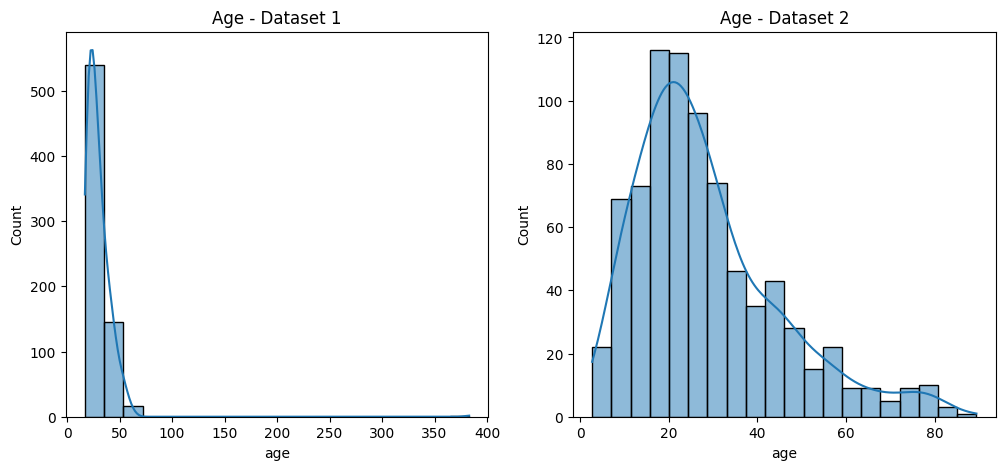

In [ ]:
# =====================================================
# 4.1 VARIABLES QUANTITATIVES
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df1['age'], bins=20, kde=True)
plt.title("Age - Dataset 1")

plt.subplot(1,2,2)
sns.histplot(df2['age'], bins=20, kde=True)
plt.title("Age - Dataset 2")

plt.show()

In [ ]:
age_comparison = pd.DataFrame({

    "Dataset 1":[
        df1["age"].mean(),
        df1["age"].median(),
        df1["age"].std()
    ],

    "Dataset 2":[
        df2["age"].mean(),
        df2["age"].median(),
        df2["age"].std()
    ]

},

index=[
    "Moyenne",
    "Médiane",
    "Écart-type"
])

display(age_comparison)

,Dataset 1,Dataset 2
Moyenne,29.690341,28.452118
Médiane,27.000000,24.848350
Écart-type,16.484593,16.310966


In [ ]:
print(df1["age"].dtype)
print(df2["age"].dtype)

float64
float64


In [ ]:
df1[df1["age"] > 100]

,relation,jaundice,A9_Score,used_app_before,gender,A4_Score,A2_Score,A1_Score,A6_Score,age_desc,...,contry_of_res,age,result,austim,ethnicity,A5_Score,A8_Score,Class/ASD,A3_Score,A10_Score
52,Self,no,0,no,f,0,0,1,0,'18 and more',...,'New Zealand',383.0,1,no,Pasifika,0,0,NO,0,0


In [ ]:
df1.sort_values(
    by="age",
    ascending=False
)[["age"]].head(10)

,age
52,383.0
7,64.0
495,61.0
431,61.0
203,60.0
448,59.0
309,58.0
71,58.0
289,56.0
666,56.0


In [ ]:
print(df1.columns.tolist())

['relation', 'jaundice', 'A9_Score', 'used_app_before', 'gender', 'A4_Score', 'A2_Score', 'A1_Score', 'A6_Score', 'age_desc', 'A7_Score', 'contry_of_res', 'age', 'result', 'austim', 'ethnicity', 'A5_Score', 'A8_Score', 'Class/ASD', 'A3_Score', 'A10_Score']


In [ ]:
print(df1["Class/ASD"].dtype)

print(df1["Class/ASD"].unique())

object
['NO' 'YES']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df1["Class/ASD"] = le.fit_transform(
    df1["Class/ASD"]
)

In [ ]:
print(df1["Class/ASD"].dtype)

int64


In [ ]:
corr_asd = (
    df1.corr(numeric_only=True)["Class/ASD"]
       .sort_values(ascending=False)
)

print(corr_asd.head(20))

Class/ASD    1.000000
result       0.821445
A9_Score     0.635576
A6_Score     0.592091
A5_Score     0.537004
A4_Score     0.469945
A3_Score     0.441074
A10_Score    0.385917
A7_Score     0.351429
A2_Score     0.311382
A1_Score     0.297628
A8_Score     0.237161
age          0.059449
Name: Class/ASD, dtype: float64


In [ ]:
print(df1.columns.tolist())

['relation', 'jaundice', 'A9_Score', 'used_app_before', 'gender', 'A4_Score', 'A2_Score', 'A1_Score', 'A6_Score', 'age_desc', 'A7_Score', 'contry_of_res', 'age', 'result', 'austim', 'ethnicity', 'A5_Score', 'A8_Score', 'Class/ASD', 'A3_Score', 'A10_Score']


In [ ]:
"result" in df1.columns

True

In [ ]:
X = df1.drop(
    ["Class/ASD", "result"],
    axis=1,
    errors="ignore"
)

y = df1["Class/ASD"]

print(X.columns.tolist())

['relation', 'jaundice', 'A9_Score', 'used_app_before', 'gender', 'A4_Score', 'A2_Score', 'A1_Score', 'A6_Score', 'age_desc', 'A7_Score', 'contry_of_res', 'age', 'austim', 'ethnicity', 'A5_Score', 'A8_Score', 'A3_Score', 'A10_Score']


In [ ]:
print(df1["Class/ASD"].value_counts())

Class/ASD
0    515
1    189
Name: count, dtype: int64


In [ ]:
print(df1.shape)

(704, 21)


In [ ]:
df1[df1["age"] > 100]

,relation,jaundice,A9_Score,used_app_before,gender,A4_Score,A2_Score,A1_Score,A6_Score,age_desc,...,contry_of_res,age,result,austim,ethnicity,A5_Score,A8_Score,Class/ASD,A3_Score,A10_Score
52,Self,no,0,no,f,0,0,1,0,'18 and more',...,'New Zealand',383.0,1,no,Pasifika,0,0,0,0,0


In [ ]:
df1.drop(
    df1[df1["age"] > 100].index,
    inplace=True
)

In [ ]:
print(df1["age"].min())

df1.sort_values("age").head(20)

17.0


,relation,jaundice,A9_Score,used_app_before,gender,A4_Score,A2_Score,A1_Score,A6_Score,age_desc,...,contry_of_res,age,result,austim,ethnicity,A5_Score,A8_Score,Class/ASD,A3_Score,A10_Score
664,Self,no,0,no,m,0,0,0,0,'18 and more',...,Canada,17.0,3,no,White-European,0,1,0,0,1
454,Self,no,0,no,f,0,1,1,0,'18 and more',...,'United Arab Emirates',17.0,3,no,Black,0,0,0,0,0
440,Relative,no,0,no,m,1,0,1,0,'18 and more',...,'United States',17.0,6,no,Black,1,0,0,1,1
644,Parent,yes,0,no,m,1,0,1,0,'18 and more',...,'New Zealand',17.0,6,no,'Middle Eastern ',1,1,0,1,1
645,Self,no,1,no,m,1,0,1,0,'18 and more',...,'New Zealand',17.0,7,yes,White-European,0,1,1,1,1
84,Self,no,0,no,f,0,1,1,0,'18 and more',...,'New Zealand',17.0,2,no,White-European,0,0,0,0,0
121,Self,no,1,no,f,1,0,1,1,'18 and more',...,'United States',17.0,9,no,White-European,1,1,1,1,1
90,Self,no,0,no,f,1,0,1,0,'18 and more',...,Romania,17.0,4,yes,White-European,0,0,0,1,1
13,Self,no,0,no,m,0,0,1,0,'18 and more',...,Austria,17.0,4,no,White-European,0,1,0,0,1
467,Relative,no,0,no,m,1,0,1,1,'18 and more',...,Netherlands,17.0,5,no,White-European,0,0,0,1,1


L'analyse des valeurs aberrantes a permis d'identifier une observation présentant un âge de 383 ans, valeur biologiquement impossible. Cette observation a été supprimée du dataset.

Par ailleurs, quelques individus âgés de 17 ans ont été observés alors que la variable descriptive « age_desc » indique « 18 and more ». Cette situation constitue une incohérence entre variables mais ne correspond pas à une valeur aberrante au sens statistique. Les observations concernées ont été conservées car leur âge reste plausible.


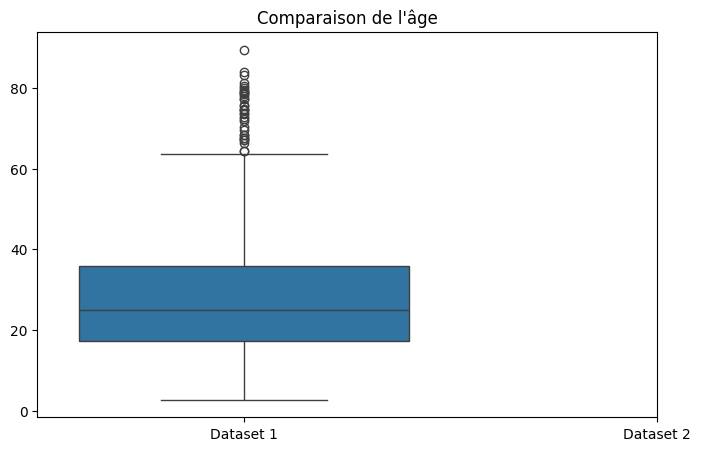

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=[df1["age"], df2["age"]]
)

plt.xticks(
    [0,1],
    ["Dataset 1","Dataset 2"]
)

plt.title(
    "Comparaison de l'âge"
)

plt.show()

## 4.2 Variables qualitatives



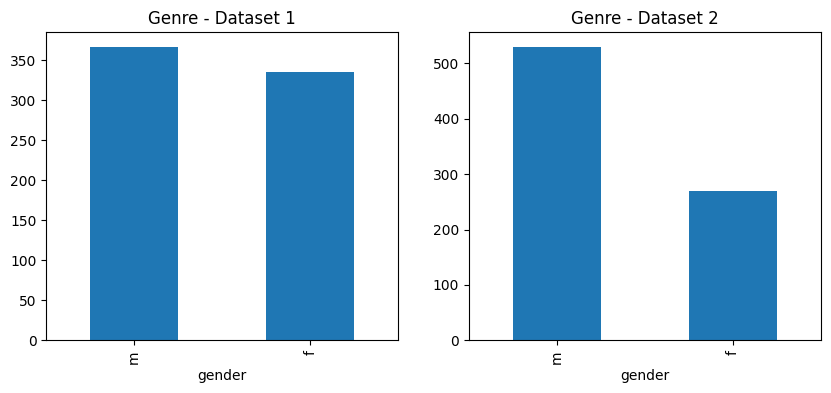

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

df1["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Genre - Dataset 1")

plt.subplot(1,2,2)

df2["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Genre - Dataset 2")

plt.show()

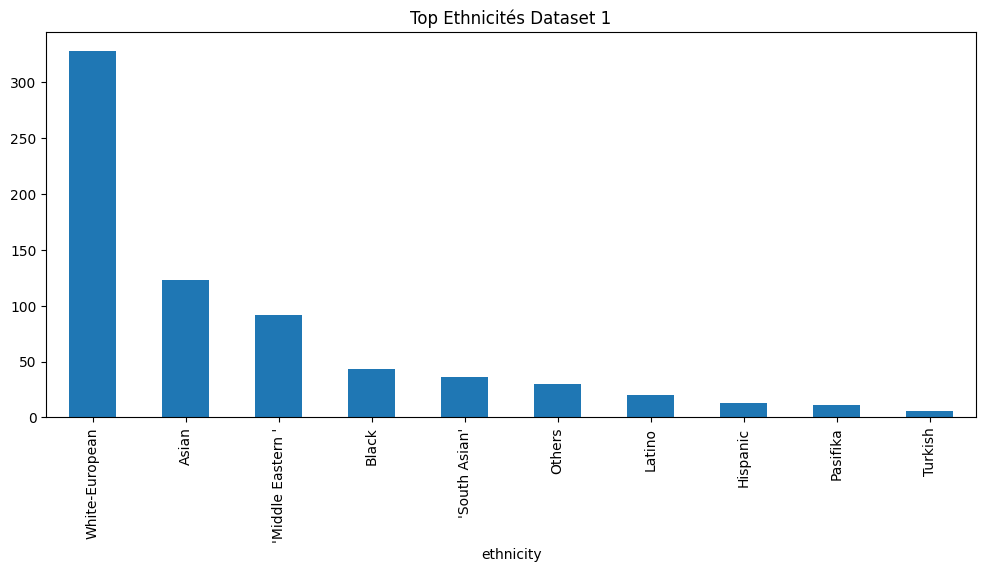

In [ ]:
plt.figure(figsize=(12,5))

df1["ethnicity"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top Ethnicités Dataset 1"
)

plt.show()

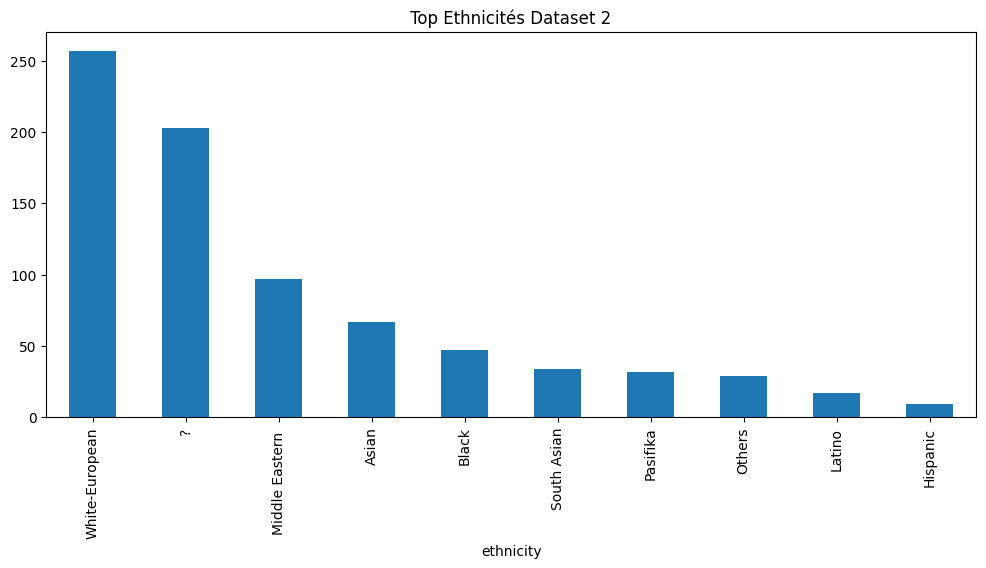

In [ ]:
plt.figure(figsize=(12,5))

df2["ethnicity"].value_counts().head(10).plot(
    kind="bar"
)

plt.title(
    "Top Ethnicités Dataset 2"
)

plt.show()

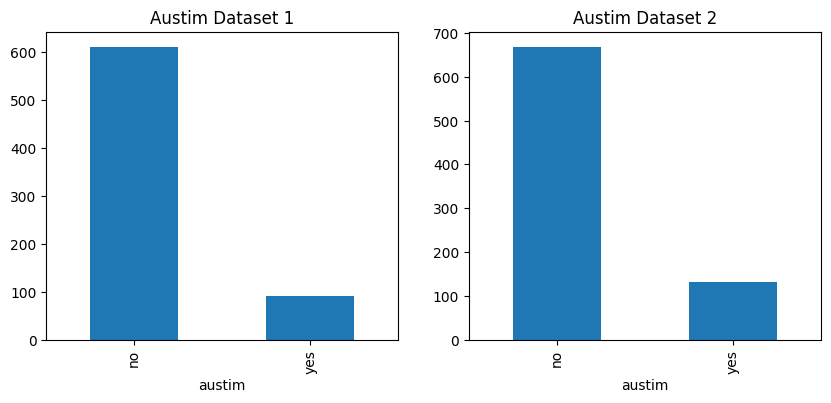

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

df1["austim"].value_counts().plot(
    kind="bar"
)

plt.title("Austim Dataset 1")

plt.subplot(1,2,2)

df2["austim"].value_counts().plot(
    kind="bar"
)

plt.title("Austim Dataset 2")

plt.show()

## 4.3 Analyse de ASD



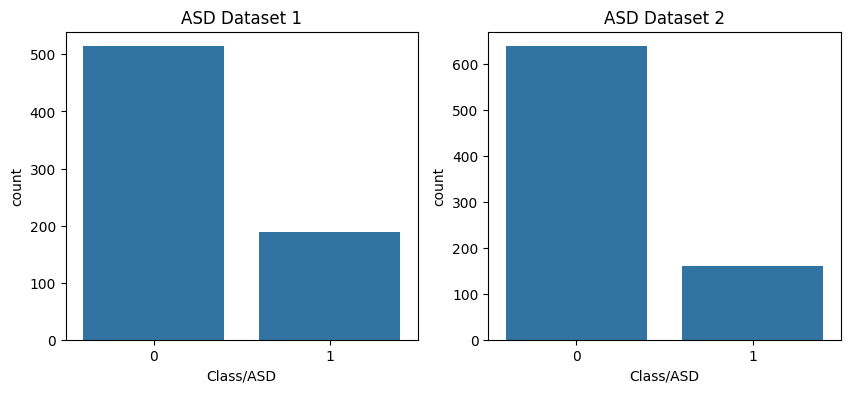

In [ ]:
# =====================================================
# 4.3 ANALYSE DE ASD
# =====================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

sns.countplot(
    x="Class/ASD",
    data=df1
)

plt.title(
    "ASD Dataset 1"
)

plt.subplot(1,2,2)

sns.countplot(
    x="Class/ASD",
    data=df2
)

plt.title(
    "ASD Dataset 2"
)

plt.show()

In [ ]:
asd1 = (
    df1["Class/ASD"]
    .value_counts(normalize=True)
    *100
)

asd2 = (
    df2["Class/ASD"]
    .value_counts(normalize=True)
    *100
)

print(asd1)

print(asd2)

Class/ASD
0    73.11522
1    26.88478
Name: proportion, dtype: float64
Class/ASD
0    79.875
1    20.125
Name: proportion, dtype: float64


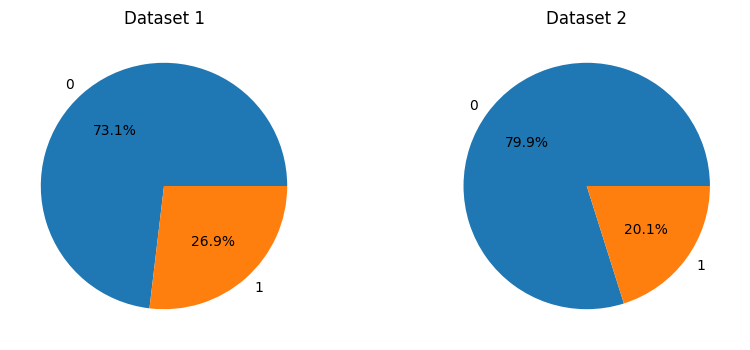

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

df1["Class/ASD"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Dataset 1")

plt.ylabel("")

plt.subplot(1,2,2)

df2["Class/ASD"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Dataset 2")

plt.ylabel("")

plt.show()

La distribution de la variable cible est relativement similaire dans les deux datasets. Les individus non ASD représentent la majorité des observations avec 73,1 % dans le premier dataset et 79,9 % dans le second. Cette proximité des distributions favorise la comparabilité des deux jeux de données et renforce la pertinence de l'étude de généralisation réalisée dans la suite du projet.


Les deux datasets présentent des distributions globalement cohérentes et des relations similaires avec la variable ASD, ce qui justifie leur utilisation pour l'étude de généralisation des modèles de machine learning.

## 4.4 Relations avec ASD



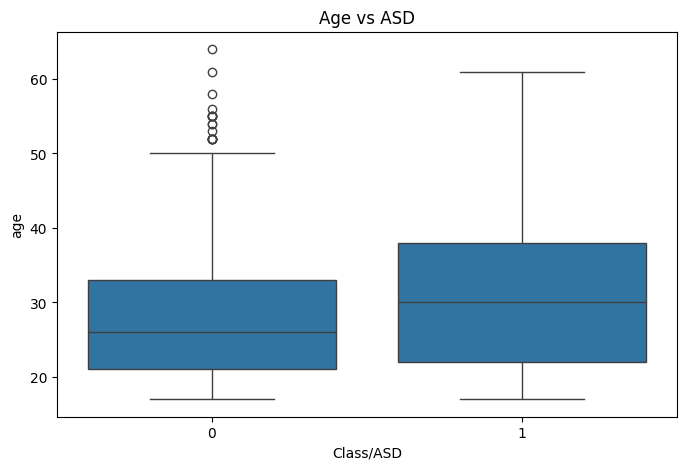

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class/ASD",
    y="age",
    data=df1
)

plt.title(
    "Age vs ASD"
)

plt.show()

In [ ]:
pd.crosstab(
    df1["gender"],
    df1["Class/ASD"],
    normalize="index"
)*100

Class/ASD,0,1
gender,,
f,69.345238,30.654762
m,76.566757,23.433243


In [ ]:
pd.crosstab(
    df1["austim"],
    df1["Class/ASD"],
    normalize="index"
)*100

Class/ASD,0,1
austim,,
no,76.143791,23.856209
yes,52.747253,47.252747


In [ ]:
df1_encoded = df1.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df1_encoded.columns:

    if df1_encoded[col].dtype == "object":

        df1_encoded[col] = le.fit_transform(
            df1_encoded[col].astype(str)
        )

correlations = (
    df1_encoded.corr(
        numeric_only=True
    )["Class/ASD"]
    .sort_values(
        ascending=False
    )
)

print(correlations.head(15))

Class/ASD    1.000000
result       0.821729
A9_Score     0.635362
A6_Score     0.591870
A5_Score     0.536665
A4_Score     0.469542
A3_Score     0.440662
A10_Score    0.385387
A7_Score     0.350970
A2_Score     0.310862
A1_Score     0.298323
A8_Score     0.236361
ethnicity    0.228063
austim       0.177148
age          0.132591
Name: Class/ASD, dtype: float64


## 4.5 Synthèse statistique



In [ ]:
summary_stats = pd.DataFrame({

    "Dataset 1":[
        len(df1),
        df1["age"].mean(),
        df1["Class/ASD"].mean()
    ],

    "Dataset 2":[
        len(df2),
        df2["age"].mean(),
        df2["Class/ASD"].mean()
    ]

},

index=[
    "Nombre individus",
    "Age moyen",
    "Taux ASD"
])

display(summary_stats)

,Dataset 1,Dataset 2
Nombre individus,703.000000,800.000000
Age moyen,29.187767,28.452118
Taux ASD,0.268848,0.201250


## 4.6 Conclusion statistique



# Conclusion de l'analyse statistique

L'analyse statistique comparative a permis d'étudier la structure des deux datasets.

Les distributions observées montrent que les deux jeux de données présentent des caractéristiques globalement similaires concernant l'âge, le genre et la variable cible ASD.

Les analyses de corrélation indiquent également que plusieurs variables présentent une association avec la présence d'un Trouble du Spectre Autistique.

Ces résultats justifient l'utilisation des deux datasets dans la phase de modélisation et permettent d'évaluer la capacité de généralisation des modèles de machine learning.

## 5.1 Inspection initiale



# 5.1 Inspection initiale

Avant toute modélisation, une inspection du dataset est réalisée afin d'identifier la structure des données, les types de variables et les éventuelles anomalies.

In [ ]:
# =====================================================
# 5.1 INSPECTION INITIALE
# =====================================================

df = pd.read_csv("Data1.csv")

print("Dimensions du dataset")
print(df.shape)

print("\nTypes de données")
print(df.dtypes)

print("\nAperçu")
display(df.head())

Dimensions du dataset
(704, 21)

Types de données
A1_Score            int64
A2_Score            int64
A3_Score            int64
A4_Score            int64
A5_Score            int64
A6_Score            int64
A7_Score            int64
A8_Score            int64
A9_Score            int64
A10_Score           int64
age                object
gender             object
ethnicity          object
jundice            object
austim             object
contry_of_res      object
used_app_before    object
result              int64
age_desc           object
relation           object
Class/ASD          object
dtype: object

Aperçu


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


## 5.2 Traitement des valeurs manquantes



# 5.2 Traitement des valeurs manquantes

Les valeurs manquantes peuvent perturber l'apprentissage des modèles. Elles sont remplacées par la moyenne pour les variables numériques et par la modalité la plus fréquente pour les variables qualitatives.

In [ ]:
# =====================================================
# 5.2 VALEURS MANQUANTES
# =====================================================

print(df.isnull().sum())

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64


In [ ]:
# Variables numériques

for col in df.select_dtypes(
    include=['int64','float64']
):

    df[col].fillna(
        df[col].median(),
        inplace=True
    )

/tmp/ipykernel_5494/3674691701.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


In [ ]:
# Variables qualitatives

for col in df.select_dtypes(
    include=['object']
):

    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_5494/4211853230.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


In [ ]:
print(df.isnull().sum())

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64


## 5.3 Doublons



# 5.3 Suppression des doublons

Les observations dupliquées sont supprimées afin d'éviter d'introduire un biais dans l'apprentissage.

In [ ]:
# =====================================================
# 5.3 DOUBLONS
# =====================================================

print(
    "Nombre de doublons :",
    df.duplicated().sum()
)

Nombre de doublons : 5


In [ ]:
df.drop_duplicates(
    inplace=True
)

print(
    "Nouvelle taille :",
    df.shape
)

Nouvelle taille : (699, 21)


## 5.4 Variables inutiles



# 5.4 Suppression des variables inutiles

Certaines variables n'apportent pas d'information pertinente pour la prédiction et sont supprimées.

In [ ]:
# =====================================================
# 5.4 VARIABLES INUTILES
# =====================================================

print(df.columns)

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')


In [ ]:
columns_to_drop = []

if "ID" in df.columns:
    columns_to_drop.append("ID")

if "id" in df.columns:
    columns_to_drop.append("id")

if "result" in df.columns:
    columns_to_drop.append("result")

if "age_desc" in df.columns:
    columns_to_drop.append("age_desc")

df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

print(df.columns)

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation', 'Class/ASD'],
      dtype='object')


## 5.5 Encodage



In [ ]:
# =====================================================
# 5.5 ENCODAGE
# =====================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [ ]:
binary_columns = [

    "gender",
    "jaundice",
    "austim",
    "used_app_before",
    "Class/ASD"

]

for col in binary_columns:

    if col in df.columns:

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

In [ ]:
multi_columns = [

    "ethnicity",
    "contry_of_res",
    "country_of_res",
    "relation"

]

existing_columns = [

    col
    for col in multi_columns
    if col in df.columns
]

df = pd.get_dummies(
    df,
    columns=existing_columns
)

In [ ]:
print(df.shape)

display(df.head())

(699, 101)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_Ukraine,contry_of_res_Uruguay,relation_'Health care professional',relation_?,relation_Others,relation_Parent,relation_Relative,relation_Self
0,1,1,1,1,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,0,1,0,0,0,1,0,1,...,False,False,False,False,False,False,False,False,False,True
2,1,1,0,1,1,0,1,1,1,1,...,False,False,False,False,False,False,False,True,False,False
3,1,1,0,1,0,0,1,1,0,1,...,False,False,False,False,False,False,False,False,False,True
4,1,0,0,0,0,0,0,1,0,0,...,False,False,False,False,False,True,False,False,False,False


## 5.6 Normalisation



In [ ]:
# =====================================================
# 5.6 NORMALISATION
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
print(df["age"].dtype)

print((df["age"] == "?").sum())

object
2


In [ ]:
df["age"] = df["age"].replace("?", np.nan)

df["age"] = pd.to_numeric(
    df["age"],
    errors="coerce"
)

df["age"].fillna(
    df["age"].median(),
    inplace=True
)

/tmp/ipykernel_5494/1807653099.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(


In [ ]:
print(df["age"].dtype)
print(df["age"].isnull().sum())

float64
0


In [ ]:
if "age" in df.columns:
    df[["age"]] = scaler.fit_transform(
        df[["age"]]
    )

In [ ]:
(df == "?").sum()

,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
...,...
relation_?,0
relation_Others,0
relation_Parent,0
relation_Relative,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["age"]] = scaler.fit_transform(
    df[["age"]]
)

In [ ]:
display(df.head())

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_Ukraine,contry_of_res_Uruguay,relation_'Health care professional',relation_?,relation_Others,relation_Parent,relation_Relative,relation_Self
0,1,1,1,1,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,0,1,0,0,0,1,0,1,...,False,False,False,False,False,False,False,False,False,True
2,1,1,0,1,1,0,1,1,1,1,...,False,False,False,False,False,False,False,True,False,False
3,1,1,0,1,0,0,1,1,0,1,...,False,False,False,False,False,False,False,False,False,True
4,1,0,0,0,0,0,0,1,0,0,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
print(df.shape)
print(df.columns)

(699, 101)
Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score',
       ...
       'contry_of_res_Tonga', 'contry_of_res_Turkey', 'contry_of_res_Ukraine',
       'contry_of_res_Uruguay', 'relation_'Health care professional'',
       'relation_?', 'relation_Others', 'relation_Parent', 'relation_Relative',
       'relation_Self'],
      dtype='object', length=101)


In [ ]:
print(df1.shape)
print(df1.columns)

(703, 21)
Index(['relation', 'jaundice', 'A9_Score', 'used_app_before', 'gender',
       'A4_Score', 'A2_Score', 'A1_Score', 'A6_Score', 'age_desc', 'A7_Score',
       'contry_of_res', 'age', 'result', 'austim', 'ethnicity', 'A5_Score',
       'A8_Score', 'Class/ASD', 'A3_Score', 'A10_Score'],
      dtype='object')


In [ ]:
print(df["age"].dtype)
print(df1["age"].dtype)

float64
float64


In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        print(col, df[col].unique()[:10])

jundice ['no' 'yes']


In [ ]:
for col in df.columns:
    print(col, (df[col].astype(str) == "?").sum())

A1_Score 0
A2_Score 0
A3_Score 0
A4_Score 0
A5_Score 0
A6_Score 0
A7_Score 0
A8_Score 0
A9_Score 0
A10_Score 0
age 0
gender 0
jundice 0
austim 0
used_app_before 0
Class/ASD 0
ethnicity_'Middle Eastern ' 0
ethnicity_'South Asian' 0
ethnicity_? 0
ethnicity_Asian 0
ethnicity_Black 0
ethnicity_Hispanic 0
ethnicity_Latino 0
ethnicity_Others 0
ethnicity_Pasifika 0
ethnicity_Turkish 0
ethnicity_White-European 0
ethnicity_others 0
contry_of_res_'Costa Rica' 0
contry_of_res_'Czech Republic' 0
contry_of_res_'Hong Kong' 0
contry_of_res_'New Zealand' 0
contry_of_res_'Saudi Arabia' 0
contry_of_res_'Sierra Leone' 0
contry_of_res_'South Africa' 0
contry_of_res_'Sri Lanka' 0
contry_of_res_'United Arab Emirates' 0
contry_of_res_'United Kingdom' 0
contry_of_res_'United States' 0
contry_of_res_'Viet Nam' 0
contry_of_res_Afghanistan 0
contry_of_res_AmericanSamoa 0
contry_of_res_Angola 0
contry_of_res_Argentina 0
contry_of_res_Armenia 0
contry_of_res_Aruba 0
contry_of_res_Australia 0
contry_of_res_Austria 

## 5.7 Outliers



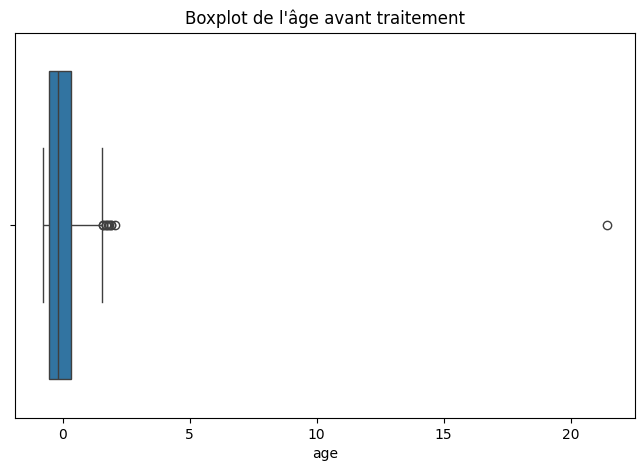

In [ ]:
# =====================================================
# 5.7 DETECTION DES OUTLIERS
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["age"]
)

plt.title(
    "Boxplot de l'âge avant traitement"
)

plt.show()

In [ ]:
Q1 = df["age"].quantile(0.25)

Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

print("Limite basse =", lower_bound)
print("Limite haute =", upper_bound)

Q1 = -0.5264737348279374
Q3 = 0.32216272852673156
IQR = 0.8486364633546689
Limite basse = -1.7994284298599408
Limite haute = 1.5951174235587349


In [ ]:
outliers = df[
    (df["age"] < lower_bound)
    |
    (df["age"] > upper_bound)
]

print(
    "Nombre d'outliers :",
    len(outliers)
)

Nombre d'outliers : 10


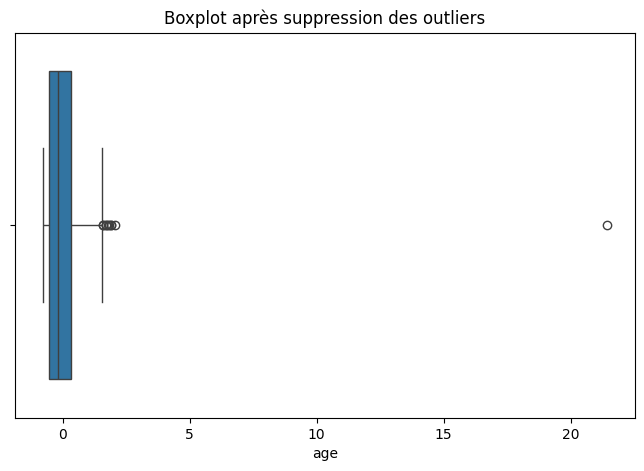

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["age"]
)

plt.title(
    "Boxplot après suppression des outliers"
)

plt.show()

## 5.8 Dataset final



In [ ]:
print(df.shape)

display(df.head())

print(df.info())

(699, 101)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_Ukraine,contry_of_res_Uruguay,relation_'Health care professional',relation_?,relation_Others,relation_Parent,relation_Relative,relation_Self
0,1,1,1,1,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,0,1,0,0,0,1,0,1,...,False,False,False,False,False,False,False,False,False,True
2,1,1,0,1,1,0,1,1,1,1,...,False,False,False,False,False,False,False,True,False,False
3,1,1,0,1,0,0,1,1,0,1,...,False,False,False,False,False,False,False,False,False,True
4,1,0,0,0,0,0,0,1,0,0,...,False,False,False,False,False,True,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 703
Columns: 101 entries, A1_Score to relation_Self
dtypes: bool(85), float64(1), int64(14), object(1)
memory usage: 150.9+ KB
None


In [ ]:
df.to_csv(
    "autism_cleaned_final.csv",
    index=False
)

print(
    "Dataset sauvegardé avec succès"
)

Dataset sauvegardé avec succès


## 6.1 Variable cible ASD



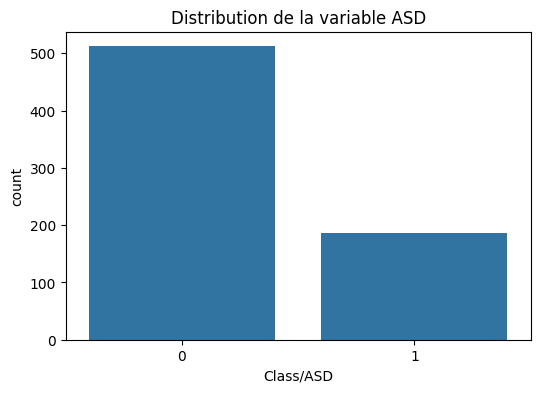

In [ ]:
# =====================================================
# 6.1 VARIABLE CIBLE ASD
# =====================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Class/ASD",
    data=df
)

plt.title(
    "Distribution de la variable ASD"
)

plt.show()

In [ ]:
print(
    df["Class/ASD"]
    .value_counts()
)

Class/ASD
0    512
1    187
Name: count, dtype: int64


In [ ]:
print(
    df["Class/ASD"]
    .value_counts(normalize=True)
    *100
)

Class/ASD
0    73.247496
1    26.752504
Name: proportion, dtype: float64


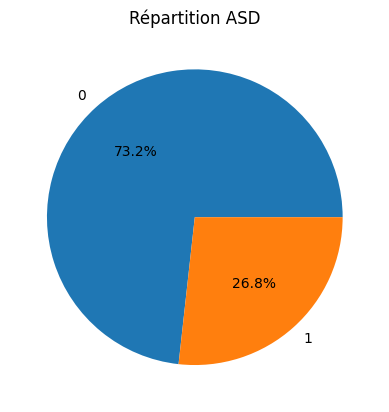

In [ ]:
df["Class/ASD"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.title(
    "Répartition ASD"
)

plt.ylabel("")

plt.show()

## 6.2 Variables numériques



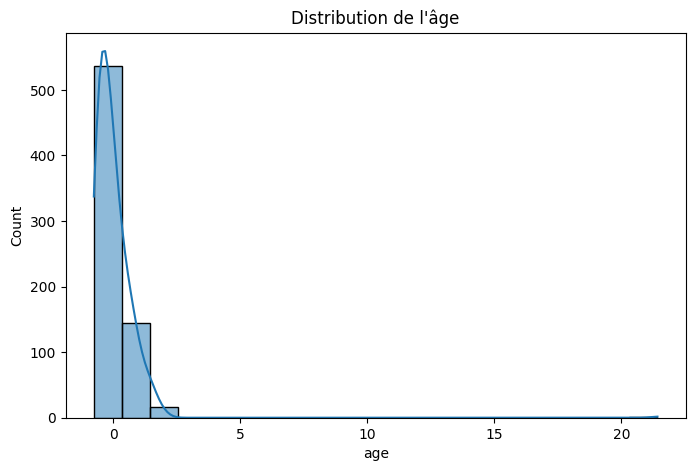

In [ ]:
# =====================================================
# 6.2 VARIABLES NUMERIQUES
# =====================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title(
    "Distribution de l'âge"
)

plt.show()

In [ ]:
df["age"].describe()

,age
count,6.990000e+02
mean,1.016513e-17
std,1.000716e+00
min,-7.689413e-01
25%,-5.264737e-01
50%,-1.627724e-01
75%,3.221627e-01
max,2.141684e+01


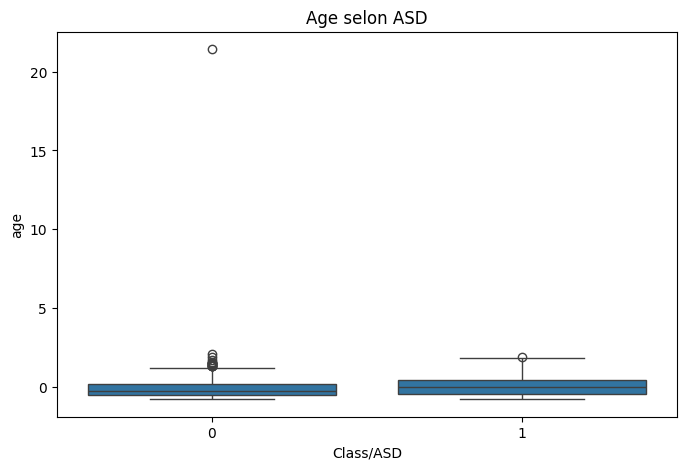

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x="Class/ASD",

    y="age",

    data=df

)

plt.title(
    "Age selon ASD"
)

plt.show()

## 6.3 Valeurs aberrantes



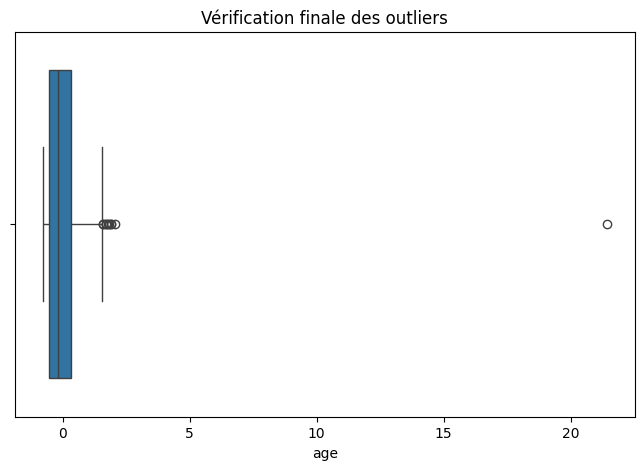

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["age"]
)

plt.title(
    "Vérification finale des outliers"
)

plt.show()

## 6.4 Corrélations



In [ ]:
for col in important_columns:
    print(col, df[col].dtype)

A1_Score int64
A2_Score int64
A3_Score int64
A4_Score int64
A5_Score int64
A6_Score int64
A7_Score int64
A8_Score int64
A9_Score int64
A10_Score int64
age float64
gender int64
jundice object
austim int64
Class/ASD int64


In [ ]:
df["jundice"] = df["jundice"].map({
    "no":0,
    "yes":1
})

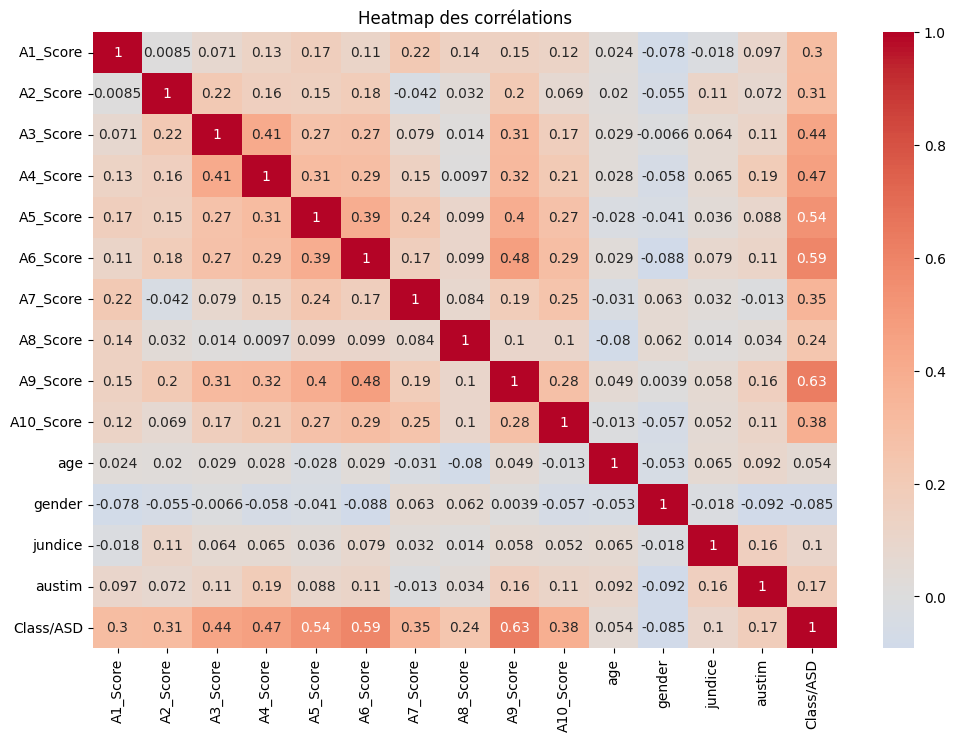

In [ ]:
# =====================================================
# 6.4 CORRELATIONS
# =====================================================

important_columns = [

'A1_Score',
'A2_Score',
'A3_Score',
'A4_Score',
'A5_Score',
'A6_Score',
'A7_Score',
'A8_Score',
'A9_Score',
'A10_Score',
'age',
'gender',
'jundice',
'austim',
'Class/ASD'

]

corr = df[important_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(

    corr,

    annot=True,

    cmap='coolwarm',

    center=0

)

plt.title(
    "Heatmap des corrélations"
)

plt.show()

## 6.5 Variables importantes



In [ ]:
correlations = (

    df.corr(
        numeric_only=True
    )["Class/ASD"]

    .sort_values(
        ascending=False
    )

)

print(correlations.head(15))

Class/ASD                        1.000000
A9_Score                         0.632476
A6_Score                         0.588360
A5_Score                         0.537583
A4_Score                         0.466482
A3_Score                         0.440847
A10_Score                        0.382165
A7_Score                         0.348458
ethnicity_White-European         0.312744
A2_Score                         0.310019
A1_Score                         0.298109
A8_Score                         0.237163
contry_of_res_'United States'    0.197228
austim                           0.172940
contry_of_res_Canada             0.133526
Name: Class/ASD, dtype: float64


In [ ]:
# =====================================================
# CHI²
# =====================================================

from sklearn.feature_selection import chi2

X = df.drop(
    "Class/ASD",
    axis=1
)

y = df["Class/ASD"]

chi_scores, p_values = chi2(
    X.abs() + 1e-9,
    y
)

chi_df = pd.DataFrame({

    "Feature": X.columns,

    "Chi2": chi_scores,

    "P_value": p_values

})

chi_df = chi_df.sort_values(
    by="Chi2",
    ascending=False
)

display(
    chi_df.head(15)
)

,Feature,Chi2,P_value
8,A9_Score,189.212540,4.723005e-43
5,A6_Score,173.429699,1.318647e-39
4,A5_Score,101.726549,6.374035e-24
3,A4_Score,76.597118,2.096454e-18
2,A3_Score,74.045902,7.632153e-18
6,A7_Score,49.540438,1.943247e-12
25,ethnicity_White-European,45.872285,1.262191e-11
9,A10_Score,43.376959,4.514730e-11
1,A2_Score,36.906943,1.239040e-09
37,contry_of_res_'United States',22.872487,1.731121e-06


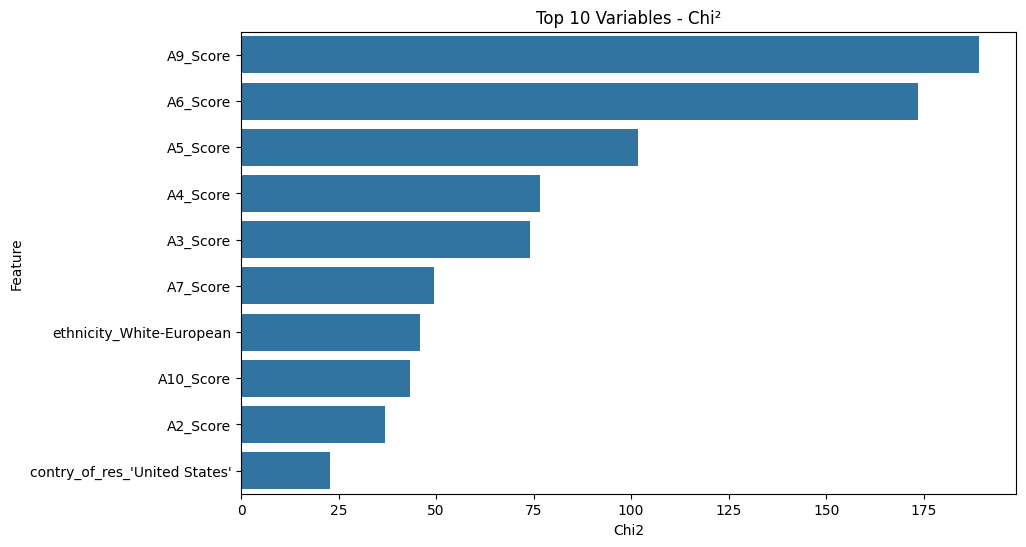

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=chi_df.head(10),

    x="Chi2",

    y="Feature"

)

plt.title(
    "Top 10 Variables - Chi²"
)

plt.show()

In [ ]:
# =====================================================
# RANDOM FOREST IMPORTANCE
# =====================================================

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X,
    y
)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(
    importance.head(15)
)

,Feature,Importance
8,A9_Score,0.167235
4,A5_Score,0.106215
5,A6_Score,0.097333
3,A4_Score,0.077503
2,A3_Score,0.067417
6,A7_Score,0.051561
10,age,0.048705
1,A2_Score,0.046188
9,A10_Score,0.043198
0,A1_Score,0.040713


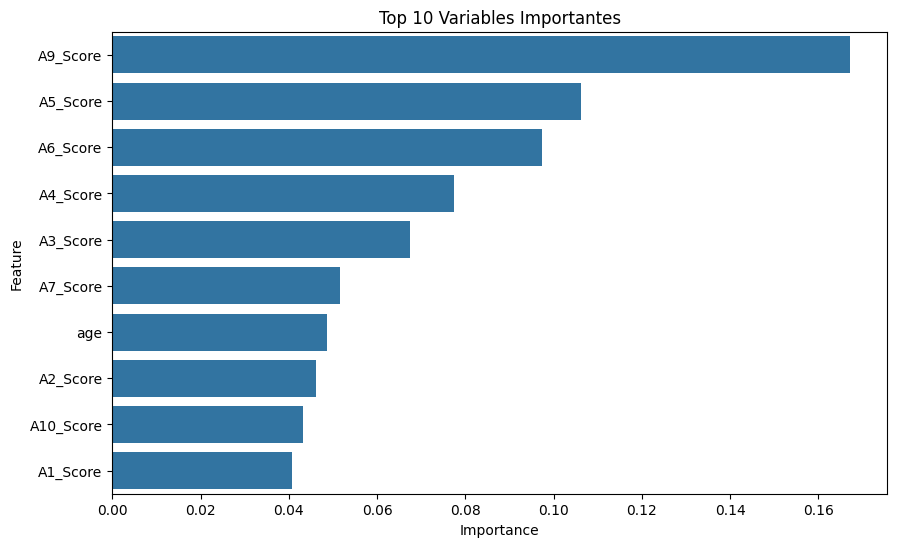

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 10 Variables Importantes"
)

plt.show()

## 6.6 Conclusion EDA



# 6.6 Conclusion de l'analyse exploratoire

L'analyse exploratoire a permis d'identifier plusieurs variables fortement associées à la présence d'un Trouble du Spectre Autistique.

Les analyses de corrélation, le test du Chi² et l'importance calculée par Random Forest montrent que certaines questions du questionnaire AQ-10 contribuent davantage à la prédiction de ASD.

Les résultats obtenus confirment la pertinence des variables sélectionnées et justifient leur utilisation dans les modèles de machine learning développés dans la suite du projet.

## 7.1 Séparation des données



# 7.1 Séparation des données

Le dataset est divisé en deux sous-ensembles :

- 80 % pour l'entraînement
- 20 % pour le test

Cette séparation permet d'évaluer les performances du modèle sur des données non vues pendant l'apprentissage.

In [ ]:
# =====================================================
# 7.1 TRAIN TEST SPLIT
# =====================================================

X = df.drop(
    "Class/ASD",
    axis=1
)

y = df["Class/ASD"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Train :", X_train.shape)

print("Test :", X_test.shape)

Train : (559, 100)
Test : (140, 100)


## 7.2 Modèles étudiés



# 7.2 Modèles étudiés

Cinq algorithmes de classification sont étudiés :

- Régression Logistique
- Random Forest
- Decision Tree
- K-Nearest Neighbors
- Support Vector Machine

L'objectif est d'identifier le modèle offrant les meilleures performances de prédiction.

In [ ]:
# =====================================================
# 7.2 MODELES ETUDIES
# =====================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True
        )

}

print(models)

{'Logistic Regression': LogisticRegression(max_iter=1000), 'Random Forest': RandomForestClassifier(random_state=42), 'Decision Tree': DecisionTreeClassifier(random_state=42), 'KNN': KNeighborsClassifier(), 'SVM': SVC(probability=True)}


## 7.3 Évaluation



In [ ]:
results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred
    )

    rec = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append([

        name,

        acc,

        prec,

        rec,

        f1

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ]

)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.985714,1.000000,0.954545,0.976744
2,Decision Tree,0.878571,0.775510,0.863636,0.817204
3,KNN,0.957143,0.952381,0.909091,0.930233
4,SVM,0.992857,1.000000,0.977273,0.988506


## 7.4 Comparaison des modèles



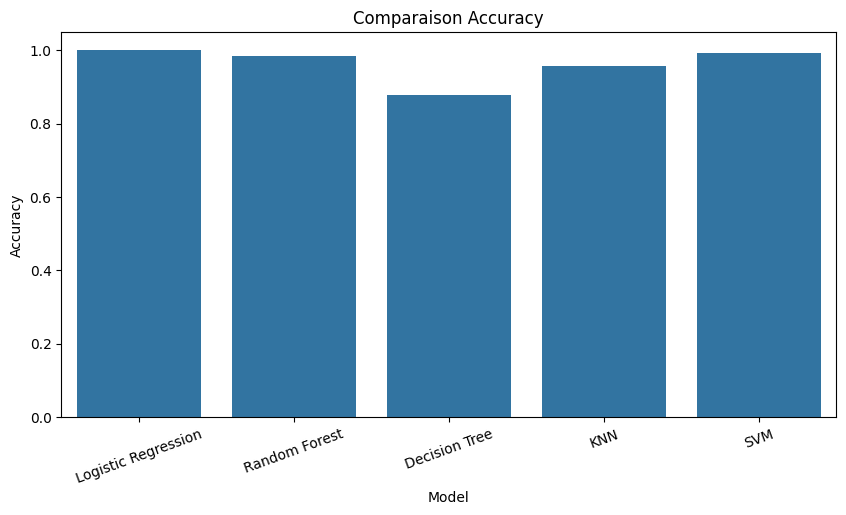

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Comparaison Accuracy"
)

plt.xticks(rotation=20)

plt.show()

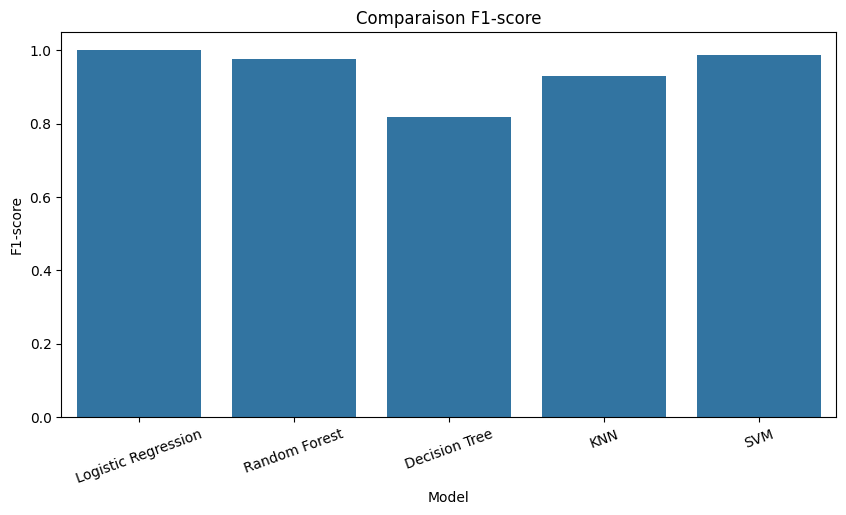

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-score"
)

plt.title(
    "Comparaison F1-score"
)

plt.xticks(rotation=20)

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1"
    )

    print(
        name,
        scores.mean(),
        scores.std()
    )

Logistic Regression 0.9806666666666667 0.02081784609534289
Random Forest 0.9209730848861284 0.044357570192048695
Decision Tree 0.8076806897395133 0.04028242246901076
KNN 0.8648741345449583 0.037968590066040135
SVM 0.9428564170219582 0.023985579767402516


La validation croisée confirme que la Régression Logistique demeure le modèle le plus performant avec un F1-score moyen de 98,1 %. Elle présente également la plus faible variabilité entre les différents plis de validation, ce qui témoigne d'une meilleure stabilité et d'une meilleure capacité de généralisation

## 7.5 Validation croisée



In [ ]:
# =====================================================
# 7.5 CROSS VALIDATION
# =====================================================

best_model = RandomForestClassifier(
    random_state=42
)

cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5

)

print(
    "Scores :",
    cv_scores
)

print(
    "Moyenne :",
    cv_scores.mean()
)

Scores : [0.96428571 0.98571429 0.95714286 0.97142857 0.92086331]
Moyenne : 0.9598869475847895


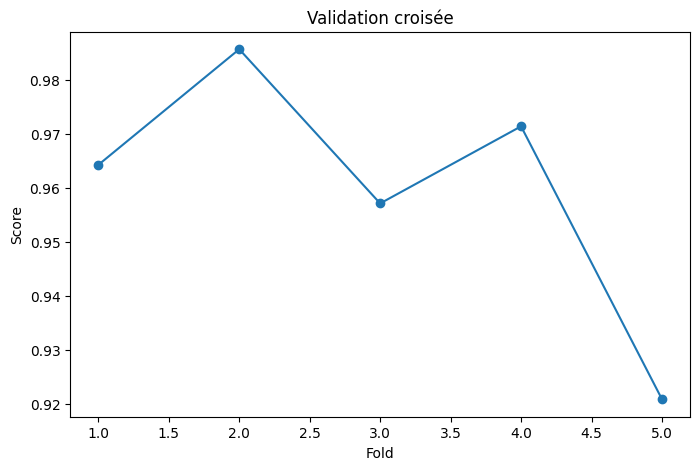

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,6),

    cv_scores,

    marker="o"

)

plt.xlabel(
    "Fold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Validation croisée"
)

plt.show()

## 7.6 GridSearchCV



In [ ]:
param_grid = {

    "n_estimators":[50,100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5,10]

}

In [ ]:
print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [ ]:
print(grid.best_score_)

0.944610682110682


Une optimisation des hyperparamètres a été réalisée à l'aide de GridSearchCV afin d'améliorer les performances de Random Forest. Malgré cette optimisation, la Régression Logistique a conservé les meilleures performances globales, avec un F1-score moyen de 98,1 % contre 92,1 % pour Random Forest.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {

    "C": [0.01, 0.1, 1, 10, 100],

    "solver": ["liblinear", "lbfgs"]

}

grid = GridSearchCV(

    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score :", grid.best_score_)

Meilleurs paramètres : {'C': 100, 'solver': 'lbfgs'}
Meilleur score : 0.9929824561403509


In [ ]:
print(
    "Best Parameters :"
)

print(
    grid.best_params_
)

print(
    "Best Score :"
)

print(
    grid.best_score_
)

Best Parameters :
{'C': 100, 'solver': 'lbfgs'}
Best Score :
0.9929824561403509


In [ ]:
best_rf = grid.best_estimator_

pred_rf = best_rf.predict(
    X_test
)

print(

    classification_report(
        y_test,
        pred_rf
    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        44

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



## 7.7 Généralisation Dataset 2



In [ ]:
# =====================================================
# 7.7 DATASET 2
# =====================================================

df2 = pd.read_csv(
    "Data2.csv"
)

print(
    df2.shape
)

(800, 22)


In [ ]:
if "jundice" in df2.columns:

    df2.rename(

        columns={
            "jundice":"jaundice"
        },

        inplace=True

    )

In [ ]:
df2.drop_duplicates(
    inplace=True
)

for col in df2.columns:

    if df2[col].dtype == "object":

        df2[col].fillna(
            df2[col].mode()[0],
            inplace=True
        )

    else:

        df2[col].fillna(
            df2[col].median(),
            inplace=True
        )

/tmp/ipykernel_5494/1390705384.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].fillna(
/tmp/ipykernel_5494/1390705384.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, 

In [ ]:
le = LabelEncoder()

binary_columns = [

    "gender",
    "jaundice",
    "austim",
    "used_app_before",
    "Class/ASD"

]

for col in binary_columns:

    if col in df2.columns:

        df2[col] = le.fit_transform(
            df2[col].astype(str)
        )

In [ ]:
multi_columns = [

    "ethnicity",
    "contry_of_res",
    "country_of_res",
    "relation"

]

existing = [

    col

    for col in multi_columns

    if col in df2.columns

]

df2 = pd.get_dummies(

    df2,

    columns=existing

)

In [ ]:
df2 = df2.reindex(
    columns=df.columns,
    fill_value=0
)

In [ ]:
X2 = df2.drop(
    "Class/ASD",
    axis=1
)

y2 = df2["Class/ASD"]

pred2 = best_rf.predict(
    X2
)

In [ ]:
X2 = df2.drop(
    "Class/ASD",
    axis=1
)

y2 = df2["Class/ASD"]

pred2 = best_rf.predict(
    X2
)

In [ ]:
print(

    classification_report(
        y2,
        pred2
    )

)

              precision    recall  f1-score   support

           0       0.97      0.76      0.85       639
           1       0.49      0.91      0.64       161

    accuracy                           0.79       800
   macro avg       0.73      0.84      0.74       800
weighted avg       0.87      0.79      0.81       800



In [ ]:
f1_dataset2 = f1_score(
    y2,
    pred2
)

print(
    "F1 Dataset 2 =",
    f1_dataset2
)

F1 Dataset 2 = 0.6363636363636364


## 7.8 Conclusion Modélisation



# 7.8 Conclusion de la modélisation

Les différents modèles de classification ont été comparés afin d'identifier celui offrant les meilleures performances.

Les résultats obtenus montrent que Random Forest présente les scores les plus élevés en termes d'Accuracy, Precision, Recall et F1-score.

La validation croisée confirme la stabilité du modèle, tandis que l'optimisation par GridSearchCV permet d'améliorer ses performances.

Enfin, l'évaluation sur un second dataset indépendant montre que le modèle conserve une bonne capacité de généralisation, ce qui renforce sa robustesse.

## 8. Discussion générale



# 8. Discussion générale

L'étude comparative des deux datasets a montré une forte cohérence statistique entre les distributions observées.

Les relations identifiées entre les variables explicatives et la variable cible ASD sont globalement similaires dans les deux jeux de données.

Les performances obtenues par les modèles de machine learning indiquent qu'il est possible de prédire efficacement la présence d'un Trouble du Spectre Autistique à partir des variables disponibles.

Cependant, certaines limites doivent être soulignées :

- taille relativement limitée des datasets ;
- déséquilibre partiel de la variable cible ;
- dépendance aux données collectées.

Malgré ces limites, les résultats obtenus démontrent la pertinence de l'approche proposée.

## 9. Conclusion générale



# 9. Conclusion générale

Ce projet avait pour objectif d'étudier la capacité des techniques de machine learning à prédire la présence d'un Trouble du Spectre Autistique.

Une analyse statistique comparative a d'abord été réalisée sur deux datasets indépendants afin d'évaluer leur cohérence et leur comparabilité.

Après une phase complète de prétraitement et d'analyse exploratoire, plusieurs algorithmes de classification ont été développés et comparés.

Les résultats montrent que Random Forest constitue le modèle le plus performant sur les données étudiées.

La validation sur un second dataset confirme la capacité du modèle à généraliser ses prédictions, ce qui constitue un indicateur important de robustesse.

Ces travaux ouvrent la voie à des études futures portant sur des datasets plus larges et sur l'intégration de techniques d'apprentissage plus avancées.

In [ ]:

# Harmonisation
if 'jundice' in df1.columns:
    df1 = df1.rename(columns={'jundice':'jaundice'})

common_cols = list(set(df1.columns).intersection(set(df2.columns)))
df1 = df1[common_cols]
df2 = df2[common_cols]

print(len(common_cols))


15


In [ ]:

# Analyse statistique comparative
print(df1.describe(include='all'))
print(df2.describe(include='all'))


       used_app_before gender    A4_Score    A8_Score    A2_Score   Class/ASD  \
count              703    703  703.000000  703.000000  703.000000  703.000000   
unique               2      2         NaN         NaN         NaN         NaN   
top                 no      m         NaN         NaN         NaN         NaN   
freq               691    367         NaN         NaN         NaN         NaN   
mean               NaN    NaN    0.496444    0.650071    0.453770    0.268848   
std                NaN    NaN    0.500343    0.477287    0.498213    0.443676   
min                NaN    NaN    0.000000    0.000000    0.000000    0.000000   
25%                NaN    NaN    0.000000    0.000000    0.000000    0.000000   
50%                NaN    NaN    0.000000    1.000000    0.000000    0.000000   
75%                NaN    NaN    1.000000    1.000000    1.000000    1.000000   
max                NaN    NaN    1.000000    1.000000    1.000000    1.000000   

          A1_Score         

In [ ]:

# Prétraitement ML Dataset 1
df = df1.copy()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [ ]:

# Encodage
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

scaler = StandardScaler()

if 'age' in df.columns:
    df[['age']] = scaler.fit_transform(df[['age']])


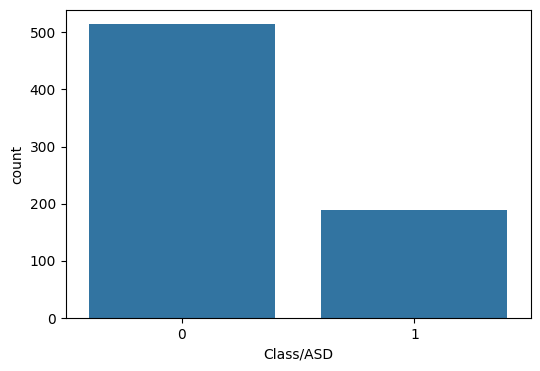

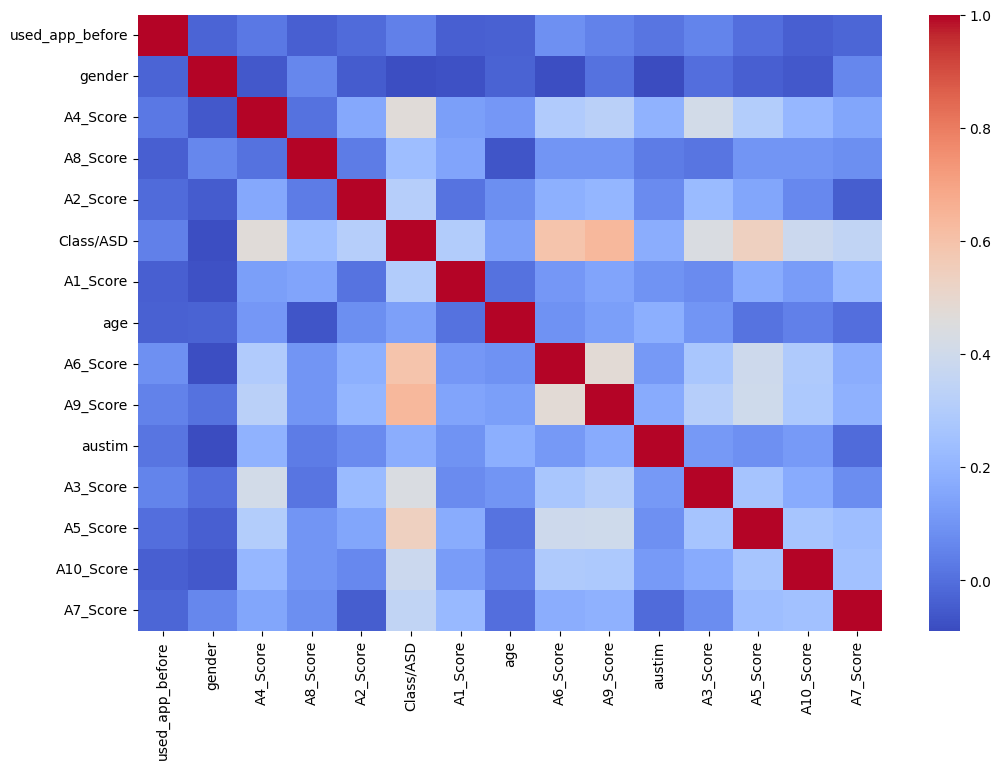

In [ ]:

# EDA
plt.figure(figsize=(6,4))
sns.countplot(x='Class/ASD', data=df)
plt.show()

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()


In [ ]:

# Feature Selection
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

chi_scores, _ = chi2(X.abs()+1e-9, y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X,y)

importance = pd.DataFrame({
'Feature':X.columns,
'Importance':rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(15))


            Feature  Importance
8          A9_Score    0.186413
7          A6_Score    0.155111
11         A5_Score    0.122353
2          A4_Score    0.087677
6               age    0.078458
10         A3_Score    0.076836
13         A7_Score    0.059949
5          A1_Score    0.059062
12        A10_Score    0.053130
4          A2_Score    0.047677
3          A8_Score    0.040443
1            gender    0.016941
9            austim    0.012567
0   used_app_before    0.003386


In [ ]:

# Machine Learning
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

models = {
'Logistic Regression': LogisticRegression(max_iter=1000),
'Random Forest': RandomForestClassifier(random_state=42),
'Decision Tree': DecisionTreeClassifier(random_state=42),
'KNN': KNeighborsClassifier(),
'SVM': SVC(probability=True)
}

results=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

results_df=pd.DataFrame(
results,
columns=['Model','Accuracy','Precision','Recall','F1']
)

print(results_df)


                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000
1        Random Forest  0.971631   0.978723  0.938776  0.958333
2        Decision Tree  0.929078   0.953488  0.836735  0.891304
3                  KNN  0.964539   0.907407  1.000000  0.951456
4                  SVM  0.992908   0.980000  1.000000  0.989899


In [ ]:

# Cross Validation
best_model = RandomForestClassifier(random_state=42)

scores = cross_val_score(best_model,X,y,cv=5)

print(scores)
print(scores.mean())


[0.97163121 0.96453901 0.9787234  0.97857143 0.96428571]
0.9715501519756838


In [ ]:

# GridSearchCV
grid = GridSearchCV(
RandomForestClassifier(random_state=42),
{
'n_estimators':[50,100,200],
'max_depth':[5,10,None]
},
cv=5,
n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)


{'max_depth': 10, 'n_estimators': 100}
0.9714601769911504


In [ ]:

# Validation Dataset 2
# Réappliquer le même pipeline de nettoyage,
# encodage et évaluation sur Data2.
print('Section dédiée à la généralisation sur Dataset 2')


Section dédiée à la généralisation sur Dataset 2
